<a href="https://colab.research.google.com/github/Manvi190502/ml/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##SVC

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
from sklearn.datasets import make_classification

In [5]:
X,y=make_classification(n_samples=1000, n_features=2,n_classes=2, n_clusters_per_class=2, n_redundant=0)
print(X.shape, y.shape)

(1000, 2) (1000,)


<Axes: xlabel='0', ylabel='1'>

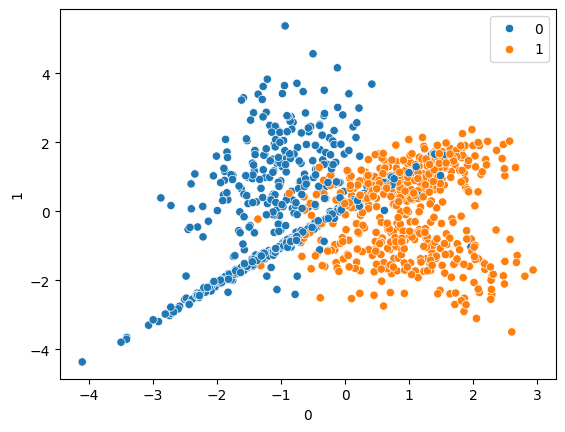

In [6]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [8]:
from sklearn.svm import SVC

In [9]:
svc=SVC(kernel='linear')

In [10]:
svc.fit(x_train,y_train)

SVC(kernel='linear')

In [11]:
svc.coef_

array([[ 2.38837993, -0.62241316]])

In [13]:
y_pred=svc.predict(x_test)

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       130
           1       0.92      0.90      0.91       120

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[120  10]
 [ 12 108]]


In [15]:
rbf=SVC(kernel='rbf')
rbf.fit(x_train,y_train)
print(classification_report(y_test,rbf.predict(x_test)))
print(confusion_matrix(y_test,rbf.predict(x_test)))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92       130
           1       0.91      0.92      0.91       120

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

[[119  11]
 [ 10 110]]


In [16]:
polynomial=SVC(kernel='poly')
polynomial.fit(x_train,y_train)
print(classification_report(y_test,polynomial.predict(x_test)))
print(confusion_matrix(y_test,polynomial.predict(x_test)))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89       130
           1       0.85      0.94      0.89       120

    accuracy                           0.89       250
   macro avg       0.89      0.89      0.89       250
weighted avg       0.90      0.89      0.89       250

[[110  20]
 [  7 113]]


In [17]:
sigmoid=SVC(kernel='sigmoid')
sigmoid.fit(x_train,y_train)
print(classification_report(y_test,sigmoid.predict(x_test)))
print(confusion_matrix(y_test,sigmoid.predict(x_test)))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       130
           1       0.85      0.85      0.85       120

    accuracy                           0.86       250
   macro avg       0.86      0.86      0.86       250
weighted avg       0.86      0.86      0.86       250

[[112  18]
 [ 18 102]]


In [18]:
sigmoid.intercept_

array([-2.25045411])

In [20]:
#HyperParameter tuning
from sklearn.model_selection import GridSearchCV
param_grid={'C': [0.1,1,10,100,1000],'gamma':[1,0.1,0.01,0.001,0.0001], 'kernel':['rbf']}
grid=GridSearchCV(SVC(),param_grid,refit=True,cv=5,verbose=3)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.933 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.927 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.907 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.900 total time=   0.1s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [21]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [22]:
y_pred=grid.predict(x_test)

In [23]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       130
           1       0.89      0.92      0.91       120

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250

[[117  13]
 [ 10 110]]


##SVM Kernel

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
x=np.linspace(-5.0,5,100)
y=np.sqrt(10**2-x**2)
y=np.hstack([y,-y])
x=np.hstack([x,-x])

In [26]:
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1=np.hstack([y1,-y1])
x1=np.hstack([x1,-x1])

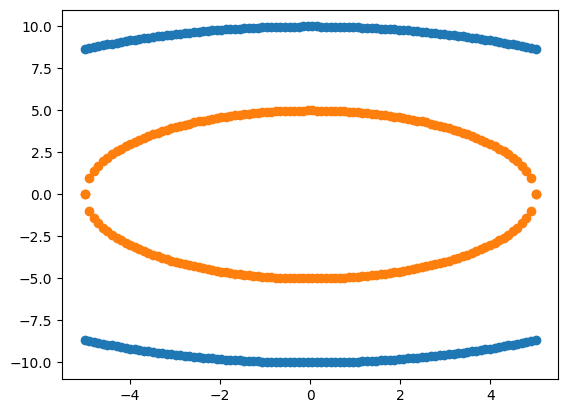

In [27]:
plt.scatter(x,y)
plt.scatter(x1,y1)

In [28]:
np.vstack([y,x]).T

array([[ 8.66025404, -5.        ],
       [ 8.71779204, -4.8989899 ],
       [ 8.77378994, -4.7979798 ],
       [ 8.82827705, -4.6969697 ],
       [ 8.88128118, -4.5959596 ],
       [ 8.93282873, -4.49494949],
       [ 8.98294476, -4.39393939],
       [ 9.03165312, -4.29292929],
       [ 9.07897646, -4.19191919],
       [ 9.12493632, -4.09090909],
       [ 9.16955321, -3.98989899],
       [ 9.21284664, -3.88888889],
       [ 9.25483518, -3.78787879],
       [ 9.29553652, -3.68686869],
       [ 9.3349675 , -3.58585859],
       [ 9.37314414, -3.48484848],
       [ 9.41008171, -3.38383838],
       [ 9.44579475, -3.28282828],
       [ 9.4802971 , -3.18181818],
       [ 9.51360192, -3.08080808],
       [ 9.54572176, -2.97979798],
       [ 9.57666854, -2.87878788],
       [ 9.60645359, -2.77777778],
       [ 9.63508769, -2.67676768],
       [ 9.66258107, -2.57575758],
       [ 9.68894344, -2.47474747],
       [ 9.714184  , -2.37373737],
       [ 9.73831149, -2.27272727],
       [ 9.76133416,

In [30]:
import pandas as pd
df1 =pd.DataFrame(np.vstack([y,x]).T,columns=['X1','X2'])
df1['Y']=0
df2 =pd.DataFrame(np.vstack([y1,x1]).T,columns=['X1','X2'])
df2['Y']=1
df = pd.concat([df1, df2], ignore_index=True)
df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [33]:
X = df.iloc[:, :2]
y=df['Y']

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [35]:
df['X1_square']=df['X1']*df['X1']
df['X2_square']=df['X2']*df['X2']
df['X1_X2']=df['X1']*df['X2']
df.head()

,X1,X2,Y,X1_square,X2_square,X1_X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [36]:
X=df[['X1','X2','X1_square','X2_square','X1_X2']]
y=df['Y']

In [37]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [41]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1_X2',
              color='Y')
fig.show()

In [44]:
fig = px.scatter_3d(df, x='X1_square', y='X2_square', z='X1_X2',
              color='Y')
fig.show()



In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='linear')
classifier.fit(x_train,y_train)
accuracy_score(y_test,classifier.predict(x_test))

1.0

In [46]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='poly')
classifier.fit(x_train,y_train)
accuracy_score(y_test,classifier.predict(x_test))

1.0

In [47]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='rbf')
classifier.fit(x_train,y_train)
accuracy_score(y_test,classifier.predict(x_test))

1.0

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
classifier=SVC(kernel='sigmoid')
classifier.fit(x_train,y_train)
accuracy_score(y_test,classifier.predict(x_test))

1.0

##SVR (Support Vector Regression)

In [49]:
import seaborn as sns
data=sns.load_dataset('tips')

In [51]:
data.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [54]:
data['sex'].value_counts()

,count
sex,
Male,157
Female,87


In [70]:
X=data[['tip','sex','smoker','day','time','size']]
y=data['total_bill']

In [71]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=10)

In [72]:
from sklearn.preprocessing import LabelEncoder
le1=LabelEncoder()
le2=LabelEncoder()
le3=LabelEncoder()
x_train['sex']=le1.fit_transform(x_train['sex'])
x_train['smoker']=le2.fit_transform(x_train['smoker'])
x_train['time']=le3.fit_transform(x_train['time'])

In [73]:
x_train.head()

,tip,sex,smoker,day,time,size
58,1.76,1,1,Sat,0,2
1,1.66,1,0,Sun,0,3
2,3.50,1,0,Sun,0,3
68,2.01,1,0,Sat,0,2
184,3.00,1,1,Sun,0,2


In [74]:
x_test['sex']=le1.transform(x_test['sex'])
x_test['smoker']=le2.transform(x_test['smoker'])
x_test['time']=le3.transform(x_test['time'])

In [75]:
#one hot encodeing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(drop='first'),[3])],remainder='passthrough')

In [76]:
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)
X_train=ct.fit_transform(x_train)

In [78]:
X_test=ct.transform(x_test)

In [79]:
from sklearn.svm import SVR
svr=SVR()
svr.fit(X_train,y_train)

SVR()

In [80]:
y_pred=svr.predict(X_test)

In [81]:
from sklearn.metrics import r2_score, mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.46028114561159283
4.1486423210190235


In [82]:
#hyper parameter tuning
from sklearn.model_selection import GridSearchCV
params={'C':[0.1,1,10,100,1000],'gamma':[1,0.1,0.01,0.001,0.0001],'kernel':['rbf']}
grid=GridSearchCV(SVR(),params,refit=True,cv=5,verbose=3)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.067 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.058 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.145 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.025 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=rbf;, score=-0.089 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.013 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.021 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=0.1, kernel=rbf;, score=-0.010 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.124 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.050 total time=   0.0s
[CV 1/5] END ....C=0.1, gamma=0.01, kernel=rbf;, score=-0.053 total time=   0.0s
[CV 2/5] END ....C=0.1, gamma=0.01, kernel=rbf;

GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [83]:
grid.best_params_

{'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}

In [84]:
print(r2_score(y_test,grid.predict(X_test)))
print(mean_absolute_error(y_test,grid.predict(X_test)))

0.5081618245078687
3.8685147526100234
